# Percobaan 1

Percobaan ini bertujuan untuk melakukan klasifikasi citra serat kayu Nantu, Palapi, dan Uru menggunakan fitur tekstur Gray Level Co-occurrence Matrix (GLCM). Tahapan yang dilakukan meliputi load data, preprocessing, ekstraksi fitur, pembagian data, pelatihan model, dan evaluasi performa klasifikasi menggunakan tiga algoritma, yaitu Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN).

Pada percobaan ini, preprocessing yang diterapkan hanya resize dan konversi grayscale tanpa tambahan filtering atau peningkatan kontras. Percobaan ini berfungsi sebagai baseline untuk membandingkan seberapa besar kontribusi tahapan preprocessing tambahan pada percobaan berikutnya terhadap efektivitas model klasifikasi.

## Import Library

Percobaan ini menggunakan beberapa library Python. **OS** digunakan untuk mengakses direktori dataset. **OpenCV (cv2)** digunakan untuk membaca citra, melakukan resize, dan konversi grayscale. **NumPy** digunakan untuk operasi array, sementara **Pandas** digunakan untuk menyusun data fitur dalam bentuk tabel. **Matplotlib** digunakan untuk visualisasi hasil preprocessing dan perbandingan akurasi model.

Untuk ekstraksi fitur tekstur, digunakan **graycomatrix** dan **graycoprops** dari library **Scikit-image** untuk menghitung matriks GLCM beserta propertinya. Pada tahap pemodelan, **train_test_split** digunakan untuk membagi data latih dan uji, sedangkan **KNeighborsClassifier**, **SVC**, dan **RandomForestClassifier** digunakan sebagai algoritma klasifikasi. Evaluasi dilakukan menggunakan **accuracy_score** dan **classification_report**.

In [ ]:
import os
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np
import pandas as pd
import math
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

## Load Data

Dataset terdiri dari citra serat kayu Nantu, Palapi, dan Uru yang tersimpan dalam tiga subfolder terpisah sesuai kelasnya. Setiap citra dibaca menggunakan OpenCV, kemudian dilakukan resize ke ukuran seragam 128×128 piksel dan konversi ke grayscale sebelum disimpan ke dalam array beserta labelnya.

Proses loading yang terstruktur ini penting untuk memastikan data yang masuk ke tahap berikutnya sudah bersih dan seragam. Ketidaksesuaian dimensi atau format citra antar kelas dapat menyebabkan ketidakkonsistenan dalam proses ekstraksi fitur yang berdampak pada performa model klasifikasi.

In [5]:
# Definisi path dan kelas
dataset_path = "Dataset"
classes = ["Palapi", "Uru", "Nantu"]
IMG_SIZE = 128

data = []
labels = []

for label in classes:
    folder = os.path.join(dataset_path, label)
    for i in range(len(os.listdir(folder))):
        filename = os.listdir(folder)[i]
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        # Resize
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
        # Grayscale
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        data.append(img)
        labels.append(label)

print("Total gambar loaded:", len(data))
print("Total label:", len(labels))

Total gambar loaded: 315
Total label: 315


## Feature Extraction

Ekstraksi fitur dilakukan menggunakan Gray Level Co-occurrence Matrix (GLCM), yaitu metode yang merepresentasikan karakteristik tekstur citra berdasarkan hubungan spasial intensitas antar piksel. Matriks GLCM dihitung pada sudut orientasi 0° dengan jarak piksel 1 menggunakan pengaturan `symmetric=True` dan `normed=True`.

Dari setiap matriks GLCM diekstrak empat fitur tekstur yaitu **Contrast**, **Correlation**, **Energy**, dan **Homogeneity**. Kelebihan GLCM terletak pada kemampuannya merepresentasikan tekstur secara kuantitatif sehingga pola serat kayu dapat dibedakan secara numerik. Namun, kualitas fitur yang dihasilkan sangat bergantung pada kualitas preprocessing yang diterapkan sebelumnya.

In [6]:
def ekstrak_glcm(img):
    glcm = graycomatrix(img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    contrast    = graycoprops(glcm, 'contrast')[0][0]
    correlation = graycoprops(glcm, 'correlation')[0][0]
    energy      = graycoprops(glcm, 'energy')[0][0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0][0]
    return [contrast, correlation, energy, homogeneity]

fitur = []
for i in range(len(data)):
    fitur.append(ekstrak_glcm(data[i]))

fitur = np.array(fitur)
labels_array = np.array(labels)

print("Shape fitur:", fitur.shape)
print("Contoh fitur pertama:", fitur[0])

Shape fitur: (315, 4)
Contoh fitur pertama: [5.82729700e+02 7.56529538e-01 1.23626759e-02 6.83088620e-02]


## Splitting Data

Data fitur yang telah diekstrak dibagi menjadi dua subset menggunakan `train_test_split`, yaitu **data latih** sebesar 80% dan **data uji** sebesar 20%. Parameter `random_state=42` digunakan untuk memastikan hasil pembagian konsisten setiap kali kode dijalankan. Parameter `stratify` diterapkan untuk menjaga proporsi setiap kelas tetap seimbang antara data latih dan data uji.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    fitur, labels_array, test_size=0.2, random_state=42, stratify=labels_array
)

print("Jumlah data train:", len(X_train))
print("Jumlah data test:", len(X_test))

Jumlah data train: 252
Jumlah data test: 63


## Modeling

Tiga algoritma klasifikasi digunakan pada percobaan ini, yaitu **Random Forest**, **Support Vector Machine (SVM)**, dan **K-Nearest Neighbor (KNN)**. Random Forest dipilih karena kemampuannya menangani hubungan non-linear. SVM dipilih karena dikenal memiliki performa baik pada data berdimensi tinggi. KNN digunakan sebagai metode berbasis jarak yang sederhana namun efektif.

Penggunaan tiga algoritma sekaligus memungkinkan perbandingan performa sehingga dapat diketahui metode yang paling sesuai untuk karakteristik fitur tekstur GLCM yang dihasilkan dari preprocessing dasar ini.

In [8]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

hasil = {}

for nama, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    hasil[nama] = acc
    print(f"=== {nama} ===")
    print(f"Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test, y_pred))
    print()

=== KNN ===
Accuracy: 47.62%
              precision    recall  f1-score   support

       Nantu       0.38      0.29      0.32        21
      Palapi       0.45      0.48      0.47        21
         Uru       0.56      0.67      0.61        21

    accuracy                           0.48        63
   macro avg       0.46      0.48      0.47        63
weighted avg       0.46      0.48      0.47        63


=== SVM ===
Accuracy: 44.44%
              precision    recall  f1-score   support

       Nantu       0.44      0.52      0.48        21
      Palapi       1.00      0.05      0.09        21
         Uru       0.43      0.76      0.55        21

    accuracy                           0.44        63
   macro avg       0.62      0.44      0.37        63
weighted avg       0.62      0.44      0.37        63


=== Random Forest ===
Accuracy: 79.37%
              precision    recall  f1-score   support

       Nantu       0.73      0.76      0.74        21
      Palapi       0.80      0

## Preprocessing

Tahap preprocessing pada percobaan ini terdiri dari dua langkah utama, yaitu **resize** dan **konversi grayscale**. Resize dilakukan untuk menyeragamkan dimensi seluruh citra menjadi 128×128 piksel agar proses ekstraksi fitur GLCM dapat berjalan secara konsisten. Konversi grayscale dilakukan untuk mengubah citra RGB menjadi satu kanal intensitas sesuai kebutuhan metode GLCM.

Percobaan ini sengaja tidak menerapkan filtering atau peningkatan kontras tambahan agar hasilnya dapat dijadikan **baseline** perbandingan terhadap percobaan berikutnya. Dengan demikian, pengaruh setiap tahapan preprocessing tambahan seperti histogram equalization dan median filter dapat diukur secara lebih objektif.

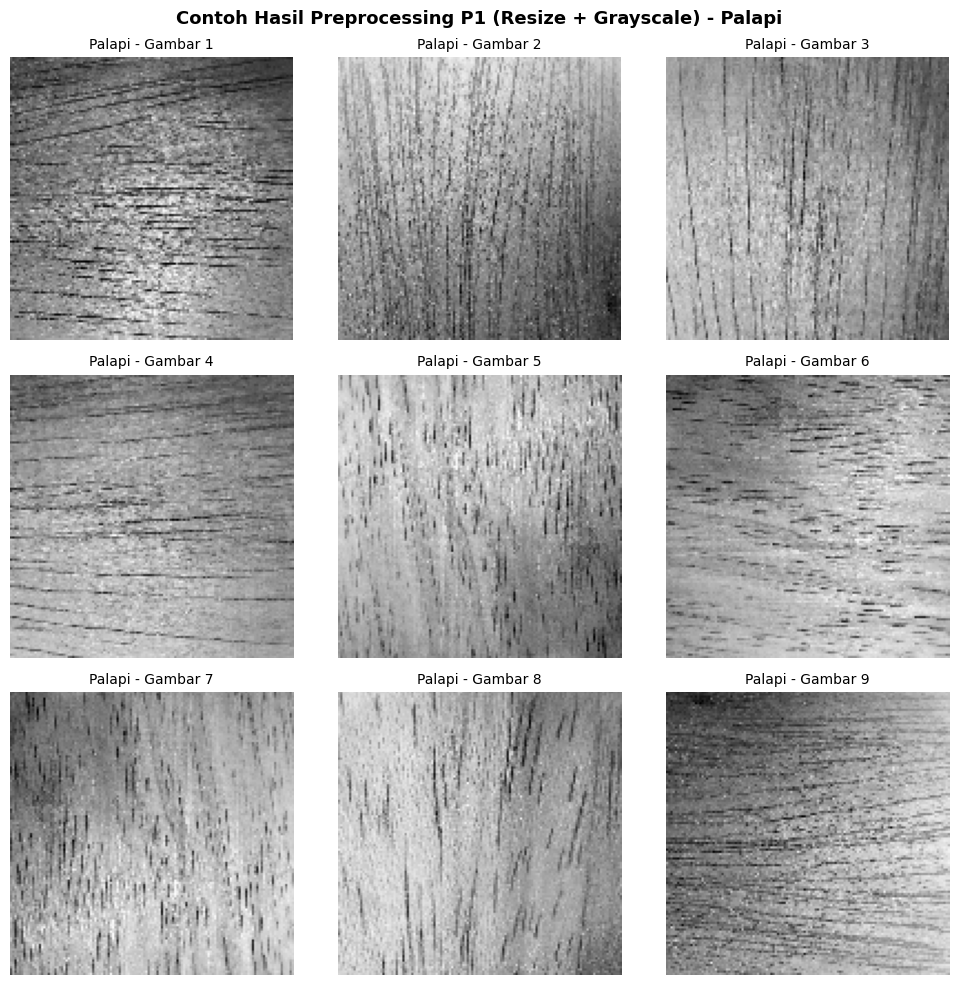

In [17]:
palapi_indices = [i for i in range(len(labels)) if labels[i] == 'Palapi']

plt.figure(figsize=(10, 10))
plt.suptitle('Contoh Hasil Preprocessing P1 (Resize + Grayscale) - Palapi', fontsize=13, fontweight='bold')

for j in range(9):
    idx = palapi_indices[j]
    plt.subplot(3, 3, j + 1)
    plt.imshow(data[idx], cmap='gray')
    plt.title(f'Palapi - Gambar {j+1}', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Evaluasi

Evaluasi dilakukan menggunakan **Accuracy** dan **Classification Report** yang mencakup Precision, Recall, dan F1-Score per kelas. Accuracy digunakan untuk mengukur tingkat prediksi yang benar secara keseluruhan, sedangkan Classification Report memberikan gambaran performa model pada masing-masing kelas Nantu, Palapi, dan Uru. Visualisasi perbandingan akurasi ketiga model ditampilkan dalam bentuk bar chart untuk memudahkan analisis.

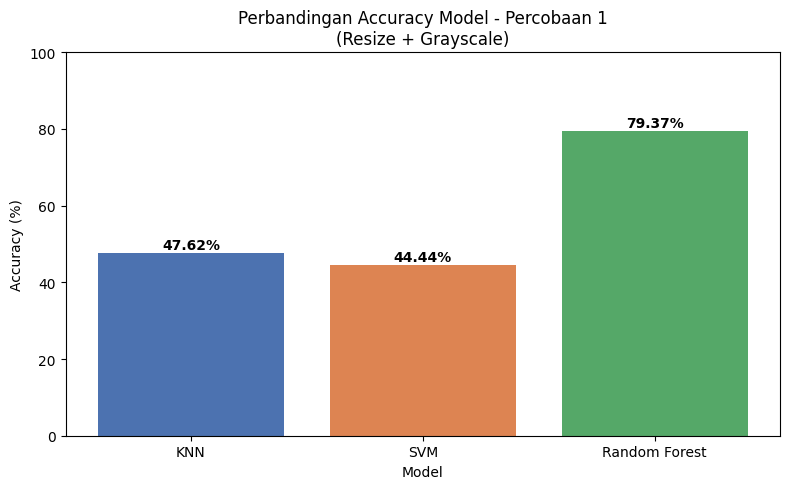

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(hasil.keys(), [v * 100 for v in hasil.values()], color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Perbandingan Accuracy Model - Percobaan 1\n(Resize + Grayscale)')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
for i, (nama, acc) in enumerate(hasil.items()):
    plt.text(i, acc * 100 + 1, f"{acc * 100:.2f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Penyimpanan Hasil Ekstraksi

Seluruh nilai fitur GLCM yang telah diekstrak disusun ke dalam sebuah DataFrame dengan kolom Contrast, Correlation, Energy, dan Homogeneity, kemudian dilengkapi dengan label kelas dan disimpan ke dalam file CSV bernama `hasil_ekstraksi_percobaan1.csv`.

Penyimpanan hasil ekstraksi dalam format CSV memungkinkan data fitur dapat diakses kembali kapan saja tanpa perlu mengulang proses komputasi GLCM dari awal, sehingga tahap pelatihan dan evaluasi model dapat dilakukan secara lebih efisien.

In [12]:
df = pd.DataFrame(fitur, columns=['contrast', 'correlation', 'energy', 'homogeneity'])
df['label'] = labels_array
df.to_csv('hasil_ekstraksi_percobaan1.csv', index=False)
print("File berhasil disimpan: hasil_ekstraksi_percobaan1.csv")

File berhasil disimpan: hasil_ekstraksi_percobaan1.csv
